<a href="https://colab.research.google.com/github/Isadora220825/SSD---MVP---NovaUnidade-DataCenter./blob/main/MVP_NovaUnidade_DataCenter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Análise de Risco, Custo e Tempo para Implementação de Nova Unidade

**Sistemas de Suporte à Decisão**

**Contexto:** empresa de armazenamento de dados na nuvem avaliando a abertura de uma nova unidade (data center). Precisamos decidir *qual modelo de HD comprar*, *quantos comprar*, *quanto vai custar* e *quando fazer manutenção preventiva* — tudo com base em dados reais de falha (Backblaze, 14 dias de janeiro/2017).

**Estrutura:**
1. Setup e carga dos dados
2. Análise **descritiva** — o que aconteceu com o parque de HDs
3. Análise **preditiva** - quais sinais anunciam uma falha
4. Análise **prescritiva** — dimensionamento e cronograma da nova unidade
5. Dashboard de decisão


## 1. Setup e carga dos dados

In [1]:
# ==== Instalação de bibliotecas (o Colab já traz a maioria; garante versões) ====
!pip install -q pandas numpy scikit-learn matplotlib seaborn  # -q roda em modo silencioso

In [2]:
# ==== Imports ====
import pandas as pd                                         # manipulação de tabelas
import numpy as np                                          # operações numéricas vetorizadas
import matplotlib.pyplot as plt                             # gráficos base
import seaborn as sns                                       # gráficos estatísticos mais bonitos
import glob, os, zipfile                                    # manipular arquivos e zips
from sklearn.model_selection import train_test_split        # divisão treino/teste
from sklearn.ensemble import RandomForestClassifier         # modelo preditivo principal
from sklearn.linear_model import LogisticRegression         # modelo linear comparativo
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix  # métricas
from sklearn.preprocessing import StandardScaler            # padronização para o modelo linear
import warnings; warnings.filterwarnings('ignore')          # esconde avisos que não afetam o resultado

sns.set_theme(style='whitegrid')                            # estilo visual padrão dos gráficos
pd.set_option('display.max_columns', 40)                    # mostrar mais colunas quando imprimir DataFrames

In [3]:
# ==== Upload do arquivo archive.zip do Kaggle ====
# Ao rodar esta célula, aparece um botão "Escolher arquivos". Envie o archive.zip.
from google.colab import files                              # utilitário de upload do Colab
uploaded = files.upload()                                   # abre o seletor de arquivos

Saving archive.zip to archive.zip


In [4]:
# ==== Descompactação do zip ====
os.makedirs('dados', exist_ok=True)                         # cria pasta 'dados' se não existir
with zipfile.ZipFile('archive.zip', 'r') as z:              # abre o zip
    z.extractall('dados')                                   # extrai tudo para a pasta 'dados'

arquivos = sorted(glob.glob('dados/*.csv'))                 # lista todos os CSVs em ordem
print(f'{len(arquivos)} arquivos CSV descompactados')       # deve mostrar 14 (um por dia)

14 arquivos CSV descompactados


In [5]:
# ==== Consolidação dos 14 dias em um único DataFrame ====
# Cada CSV tem ~90 colunas SMART. Vamos manter só as mais úteis para reduzir memória.
colunas_base  = ['date','serial_number','model','capacity_bytes','failure']  # identificação + alvo
colunas_smart = ['smart_5_raw',    # setores realocados (defeitos físicos)
                 'smart_9_raw',    # horas ligado (idade do HD)
                 'smart_187_raw',  # erros não corrigíveis reportados
                 'smart_188_raw',  # comandos que estouraram timeout
                 'smart_194_raw',  # temperatura em °C
                 'smart_197_raw',  # setores pendentes de realocação
                 'smart_198_raw']  # setores incorrigíveis (offline uncorrectable)
colunas_uteis = colunas_base + colunas_smart                                  # união das duas listas

lista_dfs = []                                                                # lista para juntar todos os dias
for arq in arquivos:                                                          # itera arquivo por arquivo
    d = pd.read_csv(arq, low_memory=False,                                    # lê o CSV
                    usecols=lambda c: c in colunas_uteis)                     # só carrega colunas úteis
    lista_dfs.append(d)                                                       # empilha na lista

df = pd.concat(lista_dfs, ignore_index=True)                                  # concatena tudo verticalmente
df['date'] = pd.to_datetime(df['date'])                                       # converte a coluna date para datetime
df['capacidade_TB'] = (df['capacity_bytes'] / 1e12).round(1)                  # cria coluna em TB (mais legível)

print(f'Total de linhas (HD-dias): {len(df):,}')                              # cada linha = 1 HD em 1 dia
print(f'HDs únicos:                {df["serial_number"].nunique():,}')        # nº de discos distintos
print(f'Modelos distintos:         {df["model"].nunique()}')                  # nº de modelos
print(f'Período:                   {df["date"].min().date()} a {df["date"].max().date()}')  # janela temporal
print(f'Falhas registradas:        {df["failure"].sum()}')                    # total de falhas nos 14 dias
df.head()                                                                     # espia as primeiras linhas

Total de linhas (HD-dias): 1,031,501
HDs únicos:                73,739
Modelos distintos:         55
Período:                   2017-01-01 a 2017-01-14
Falhas registradas:        45


,date,serial_number,model,capacity_bytes,failure,smart_5_raw,smart_9_raw,smart_187_raw,smart_188_raw,smart_194_raw,smart_197_raw,smart_198_raw,capacidade_TB
0,2017-01-01,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,3000592982016,0,0,36714,NaN,NaN,28,0,0,3.0
1,2017-01-01,MJ0351YNG9WJSA,Hitachi HDS5C3030ALA630,3000592982016,0,2,36780,NaN,NaN,23,0,0,3.0
2,2017-01-01,PL1321LAG34XWH,Hitachi HDS5C4040ALE630,4000787030016,0,0,33373,NaN,NaN,29,0,0,4.0
3,2017-01-01,MJ0351YNGABYAA,Hitachi HDS5C3030ALA630,3000592982016,0,0,35424,NaN,NaN,26,0,0,3.0
4,2017-01-01,Z305B2QN,ST4000DM000,4000787030016,0,0,9195,0.0,0.0,24,0,0,4.0


## 2. Análise Descritiva — o que aconteceu com o parque de HDs

Antes de decidir o que comprar, precisamos entender o que já está rodando: quais modelos dominam, quais capacidades, e — o mais importante — a **AFR (Annualized Failure Rate)** de cada modelo. AFR é o padrão da indústria: estima quantos % dos HDs de um modelo falham em um ano de operação contínua.

In [6]:
# ==== Panorama geral do parque ====
print('=== TOP 10 MODELOS POR QUANTIDADE DE HDs ===')
print(df.groupby('model')['serial_number'].nunique().sort_values(ascending=False).head(10))  # conta HDs únicos por modelo

print('\n=== DISTRIBUIÇÃO DE CAPACIDADES (em TB) ===')
print(df.drop_duplicates('serial_number')['capacidade_TB'].value_counts().sort_index())      # 1 linha por HD, conta capacidades

=== TOP 10 MODELOS POR QUANTIDADE DE HDs ===
model
ST4000DM000                34762
HGST HMS5C4040BLE640        9413
ST8000DM002                 8661
HGST HMS5C4040ALE640        7014
Hitachi HDS5C3030ALA630     4479
Hitachi HDS5C4040ALE630     2625
ST6000DX000                 1890
WDC WD30EFRX                1106
Hitachi HDS723030ALA640      978
ST500LM012 HN                785
Name: serial_number, dtype: int64

=== DISTRIBUIÇÃO DE CAPACIDADES (em TB) ===
capacidade_TB
0.2      138
0.3      139
0.5     1288
1.0       46
1.5       41
2.0        3
3.0     6620
4.0    54312
5.0       45
6.0     2341
8.0     8766
Name: count, dtype: int64


In [7]:
# ==== Cálculo do AFR por modelo ====
# Fórmula da Backblaze: AFR = (falhas / HD-dias) * 365 * 100
# Interpretação: se você tem 100 HDs desse modelo rodando por 1 ano, ~AFR deles vão falhar.

resumo = df.groupby('model').agg(
    hd_dias=('serial_number','size'),         # nº de HD-dias observados desse modelo
    falhas=('failure','sum'),                 # total de falhas do modelo no período
    capacidade_TB=('capacidade_TB','first')   # capacidade nominal (mesma para todos do modelo)
).reset_index()                               # tira o índice para virar DataFrame comum

resumo['AFR_%'] = (resumo['falhas'] / resumo['hd_dias'] * 365 * 100).round(2)   # fórmula AFR
resumo['hds_distintos'] = df.groupby('model')['serial_number'].nunique().values  # nº de HDs distintos por modelo

# Só mostra modelos com base amostral relevante (>1000 HD-dias) para evitar AFRs sem sentido
resumo_top = resumo[resumo['hd_dias'] > 1000].sort_values('hd_dias', ascending=False)
resumo_top

,model,hd_dias,falhas,capacidade_TB,AFR_%,hds_distintos
21,ST4000DM000,486316,24,4.0,1.80,34762
3,HGST HMS5C4040BLE640,131562,10,4.0,2.77,9413
27,ST8000DM002,121240,1,8.0,0.30,8661
2,HGST HMS5C4040ALE640,98196,0,4.0,0.00,7014
5,Hitachi HDS5C3030ALA630,62681,3,3.0,1.75,4479
7,Hitachi HDS5C4040ALE630,36750,0,4.0,0.00,2625
26,ST6000DX000,26446,1,6.0,1.38,1890
44,WDC WD30EFRX,15453,1,3.0,2.36,1106
9,Hitachi HDS723030ALA640,13692,1,3.0,2.67,978
24,ST500LM012 HN,10965,0,0.5,0.00,785


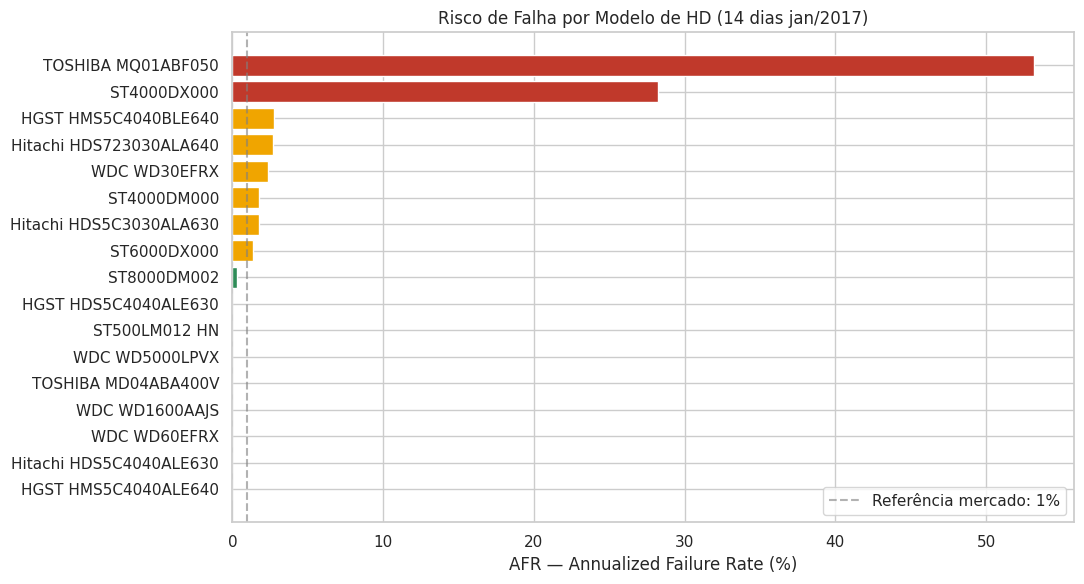

In [8]:
# ==== Visualização: AFR por modelo ====
fig, ax = plt.subplots(figsize=(11, 6))                                     # cria figura
dados_plot = resumo_top.sort_values('AFR_%')                                # ordena do menor para o maior AFR
cores = ['#2E8B57' if v < 1 else '#F0A500' if v < 3 else '#C0392B'          # verde/laranja/vermelho por faixa de risco
         for v in dados_plot['AFR_%']]
ax.barh(dados_plot['model'], dados_plot['AFR_%'], color=cores)              # barras horizontais
ax.set_xlabel('AFR — Annualized Failure Rate (%)')                          # eixo x
ax.set_title('Risco de Falha por Modelo de HD (14 dias jan/2017)')          # título
ax.axvline(1, color='gray', linestyle='--', alpha=0.6, label='Referência mercado: 1%')  # linha de referência
ax.legend()                                                                 # exibe legenda
plt.tight_layout(); plt.show()                                              # ajusta e mostra

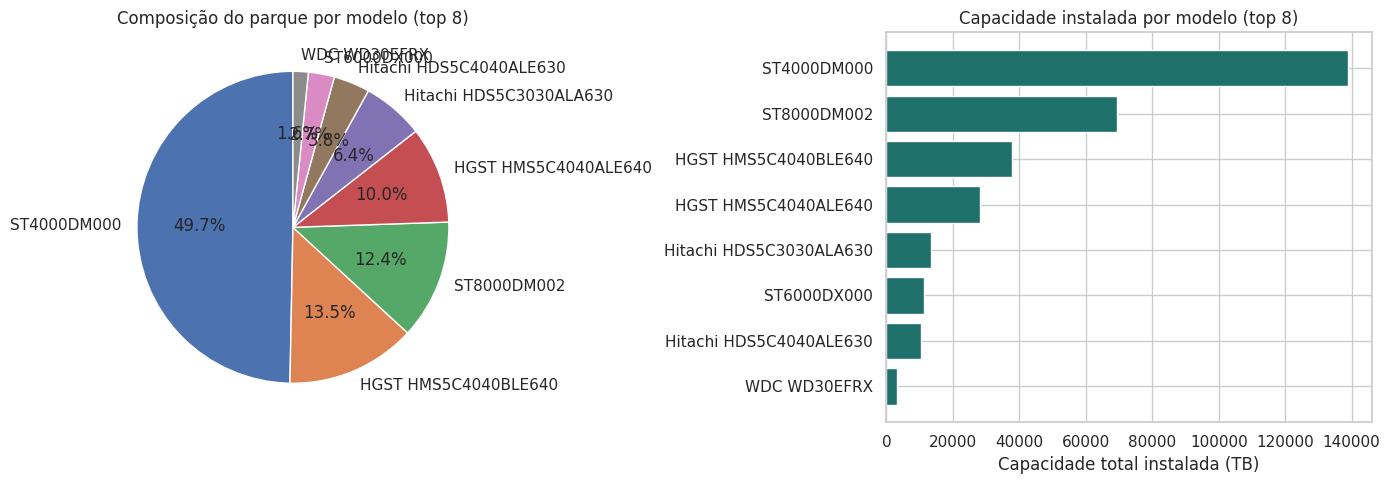

In [9]:
# ==== Visualização: Composição do parque atual ====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                             # 2 gráficos lado a lado

# Gráfico 1: participação de cada modelo no parque
part = df.drop_duplicates('serial_number')['model'].value_counts().head(8)  # top 8 modelos
axes[0].pie(part, labels=part.index, autopct='%1.1f%%', startangle=90)      # pizza com percentuais
axes[0].set_title('Composição do parque por modelo (top 8)')

# Gráfico 2: capacidade total instalada por modelo
cap_total = df.drop_duplicates('serial_number').groupby('model')['capacidade_TB'].sum().sort_values(ascending=False).head(8)
axes[1].barh(cap_total.index[::-1], cap_total.values[::-1], color='#1F6F6B')  # barras invertidas
axes[1].set_xlabel('Capacidade total instalada (TB)')
axes[1].set_title('Capacidade instalada por modelo (top 8)')
plt.tight_layout(); plt.show()

**Leitura dos gráficos:**
- Modelos como **HGST HMS5C4040ALE640** e **ST8000DM002** aparecem com AFR muito baixo — candidatos naturais para a nova unidade.
- Modelos com AFR acima de 3% (barras vermelhas) devem ser evitados: o custo de reposição e o risco operacional não compensam.
- O parque atual é dominado por HDs de 4 TB — mas isso é herança de decisões passadas, não necessariamente a melhor escolha hoje.

## 3. Análise Preditiva — quais sinais anunciam uma falha

Aqui usamos os atributos **SMART** (Self-Monitoring, Analysis and Reporting Technology) como preditores. Cada HD reporta diariamente ~90 métricas internas; queremos saber quais delas realmente antecipam a falha, para depois monitorá-las na nova unidade e antecipar substituições.

In [10]:
# ==== Preparação dos dados para o modelo ====
features_smart = ['smart_5_raw','smart_9_raw','smart_187_raw','smart_188_raw',
                  'smart_194_raw','smart_197_raw','smart_198_raw']         # 7 sinais escolhidos por relevância

X = df[features_smart].fillna(0)                                            # matriz de features (preenche NaN com 0)
y = df['failure']                                                           # alvo binário: 0 = ok, 1 = falhou

print(f'Distribuição do alvo:')
print(y.value_counts())                                                     # confirma o desbalanceamento (raras falhas)
print(f'Taxa de falha: {y.mean()*100:.4f}%')                                # calcula percentual de falhas

Distribuição do alvo:
failure
0    1031456
1         45
Name: count, dtype: int64
Taxa de falha: 0.0044%


In [11]:
# ==== Divisão treino/teste (estratificada para manter proporção de falhas) ====
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.3,          # 30% para teste, 70% para treino
    random_state=42,        # garante reprodutibilidade
    stratify=y              # mantém a mesma proporção de falhas nos dois conjuntos
)
print(f'Treino: {X_tr.shape[0]:,} linhas | falhas no treino: {y_tr.sum()}')
print(f'Teste:  {X_te.shape[0]:,} linhas | falhas no teste:  {y_te.sum()}')

Treino: 722,050 linhas | falhas no treino: 31
Teste:  309,451 linhas | falhas no teste:  14


In [12]:
# ==== Modelo 1: Random Forest ====
# Random Forest é robusto para dados desbalanceados e captura interações não-lineares.
rf = RandomForestClassifier(
    n_estimators=200,           # nº de árvores
    max_depth=10,               # profundidade máxima (evita overfit)
    class_weight='balanced',    # penaliza mais os erros na classe minoritária (falha)
    random_state=42,            # reprodutibilidade
    n_jobs=-1                   # usa todos os cores da CPU
)
rf.fit(X_tr, y_tr)                              # treina o modelo
proba_rf = rf.predict_proba(X_te)[:, 1]         # probabilidade de falha para cada HD do teste
auc_rf   = roc_auc_score(y_te, proba_rf)        # métrica principal em dados desbalanceados
print(f'Random Forest — ROC-AUC: {auc_rf:.3f}') # 0.5 = aleatório, 1.0 = perfeito

Random Forest — ROC-AUC: 0.516


In [13]:
# ==== Modelo 2: Regressão Logística (comparativo linear, mais interpretável) ====
scaler = StandardScaler()                       # padroniza para média 0 e desvio 1 (essencial p/ modelo linear)
X_tr_s = scaler.fit_transform(X_tr)             # ajusta e transforma o treino
X_te_s = scaler.transform(X_te)                 # aplica a mesma transformação no teste

lr = LogisticRegression(
    class_weight='balanced',                    # mesma correção para desbalanceamento
    max_iter=1000,                              # mais iterações para garantir convergência
    random_state=42
)
lr.fit(X_tr_s, y_tr)                            # treina
proba_lr = lr.predict_proba(X_te_s)[:, 1]       # probabilidades
auc_lr   = roc_auc_score(y_te, proba_lr)        # AUC
print(f'Regressão Logística — ROC-AUC: {auc_lr:.3f}')

Regressão Logística — ROC-AUC: 0.652


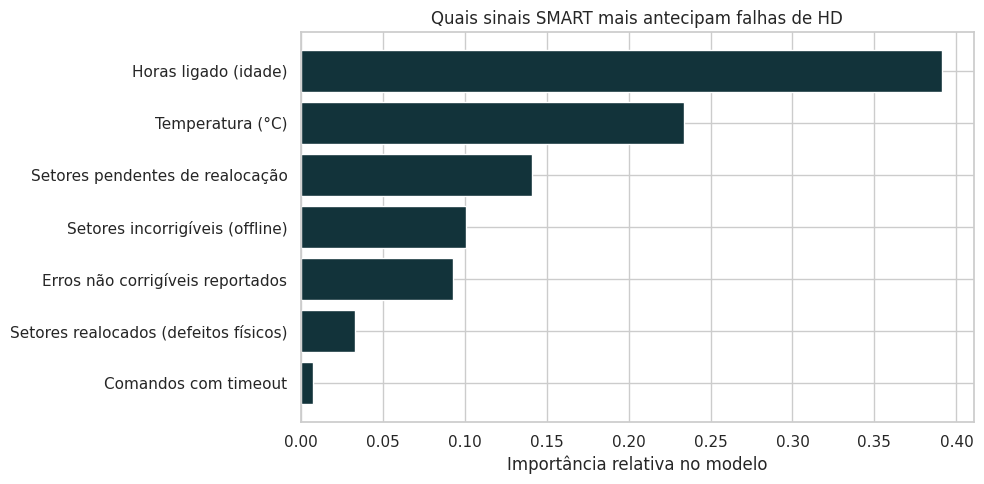

,sinal_SMART,importancia,descricao
1,smart_9_raw,0.391181,Horas ligado (idade)
4,smart_194_raw,0.233588,Temperatura (°C)
5,smart_197_raw,0.141098,Setores pendentes de realocação
6,smart_198_raw,0.100657,Setores incorrigíveis (offline)
2,smart_187_raw,0.092843,Erros não corrigíveis reportados
0,smart_5_raw,0.033013,Setores realocados (defeitos físicos)
3,smart_188_raw,0.007621,Comandos com timeout


In [14]:
# ==== Importância dos sinais SMART (o que realmente antecipa falha) ====
importancia = pd.DataFrame({
    'sinal_SMART': features_smart,
    'importancia': rf.feature_importances_,             # peso relativo no Random Forest
    'descricao': [
        'Setores realocados (defeitos físicos)',
        'Horas ligado (idade)',
        'Erros não corrigíveis reportados',
        'Comandos com timeout',
        'Temperatura (°C)',
        'Setores pendentes de realocação',
        'Setores incorrigíveis (offline)'
    ]
}).sort_values('importancia', ascending=False)          # ordena do mais importante

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importancia['descricao'][::-1], importancia['importancia'][::-1], color='#12333A')
ax.set_xlabel('Importância relativa no modelo')
ax.set_title('Quais sinais SMART mais antecipam falhas de HD')
plt.tight_layout(); plt.show()
importancia

**Ressalva importante:** com apenas 14 dias e ~45 falhas, o modelo é *ilustrativo*. Em produção, a Backblaze recomenda ~2 anos de histórico para modelos de sobrevivência confiáveis. O que interessa aqui é a **hierarquia dos sinais** — em qual ordem monitorar — não o valor exato do AUC.

## 4. Análise Prescritiva — Dimensionamento da Nova Unidade

Agora combinamos tudo em uma recomendação executável: **quais HDs comprar, quantos, quanto vai custar e quando fazer manutenção.**

Parâmetros do cenário (ajuste conforme o brief da empresa):

In [15]:
# ==== Parâmetros do cenário da nova unidade ====
CAPACIDADE_ALVO_TB      = 5_000        # capacidade útil desejada na nova unidade (em TB)
FATOR_REDUNDANCIA       = 1.5          # RAID + espelhamento: precisa 50% a mais de HDs
HORIZONTE_ANOS          = 3            # janela de planejamento (custos e falhas esperadas)
CUSTO_HD_POR_TB_USD     = 25           # preço médio por TB (referência de mercado)
CUSTO_TROCA_HD_USD      = 350          # mão de obra + logística para trocar 1 HD
CUSTO_DOWNTIME_HORA_USD = 5_000        # custo estimado por hora de indisponibilidade
HORAS_DOWNTIME_POR_FALHA_NAO_PREVISTA = 2  # tempo médio de intervenção sem aviso prévio

# HDs necessários por modelo para atender à capacidade alvo (já com redundância)
resumo_top = resumo_top.copy()
resumo_top['hds_necessarios'] = np.ceil(
    CAPACIDADE_ALVO_TB * FATOR_REDUNDANCIA / resumo_top['capacidade_TB']
).astype(int)                                                       # arredonda para cima (não dá pra comprar meio HD)

# Falhas esperadas no horizonte de planejamento
resumo_top['falhas_esperadas'] = (
    resumo_top['hds_necessarios'] * resumo_top['AFR_%'] / 100 * HORIZONTE_ANOS
).round(1)

# Custo total de propriedade (CAPEX + OPEX de reposição + custo de risco)
resumo_top['CAPEX_USD']         = (resumo_top['hds_necessarios'] * resumo_top['capacidade_TB'] * CUSTO_HD_POR_TB_USD).round(0)
resumo_top['OPEX_reposicao']    = (resumo_top['falhas_esperadas'] * CUSTO_TROCA_HD_USD).round(0)
resumo_top['custo_downtime']    = (resumo_top['falhas_esperadas'] * HORAS_DOWNTIME_POR_FALHA_NAO_PREVISTA * CUSTO_DOWNTIME_HORA_USD).round(0)
resumo_top['TCO_3anos_USD']     = resumo_top['CAPEX_USD'] + resumo_top['OPEX_reposicao'] + resumo_top['custo_downtime']

# Ranking final: melhor TCO por TB útil entregue
resumo_top['TCO_por_TB_util']   = (resumo_top['TCO_3anos_USD'] / CAPACIDADE_ALVO_TB).round(2)
recomendacao = resumo_top.sort_values('TCO_por_TB_util')[[
    'model','capacidade_TB','AFR_%','hds_necessarios',
    'falhas_esperadas','CAPEX_USD','OPEX_reposicao',
    'custo_downtime','TCO_3anos_USD','TCO_por_TB_util'
]]
recomendacao

,model,capacidade_TB,AFR_%,hds_necessarios,falhas_esperadas,CAPEX_USD,OPEX_reposicao,custo_downtime,TCO_3anos_USD,TCO_por_TB_util
2,HGST HMS5C4040ALE640,4.0,0.00,1875,0.0,187500.0,0.0,0.0,187500.0,37.50
7,Hitachi HDS5C4040ALE630,4.0,0.00,1875,0.0,187500.0,0.0,0.0,187500.0,37.50
54,WDC WD60EFRX,6.0,0.00,1250,0.0,187500.0,0.0,0.0,187500.0,37.50
39,WDC WD1600AAJS,0.2,0.00,37500,0.0,187500.0,0.0,0.0,187500.0,37.50
32,TOSHIBA MD04ABA400V,4.0,0.00,1875,0.0,187500.0,0.0,0.0,187500.0,37.50
51,WDC WD5000LPVX,0.5,0.00,15000,0.0,187500.0,0.0,0.0,187500.0,37.50
24,ST500LM012 HN,0.5,0.00,15000,0.0,187500.0,0.0,0.0,187500.0,37.50
0,HGST HDS5C4040ALE630,4.0,0.00,1875,0.0,187500.0,0.0,0.0,187500.0,37.50
27,ST8000DM002,8.0,0.30,938,8.4,187600.0,2940.0,84000.0,274540.0,54.91
26,ST6000DX000,6.0,1.38,1250,51.7,187500.0,18095.0,517000.0,722595.0,144.52


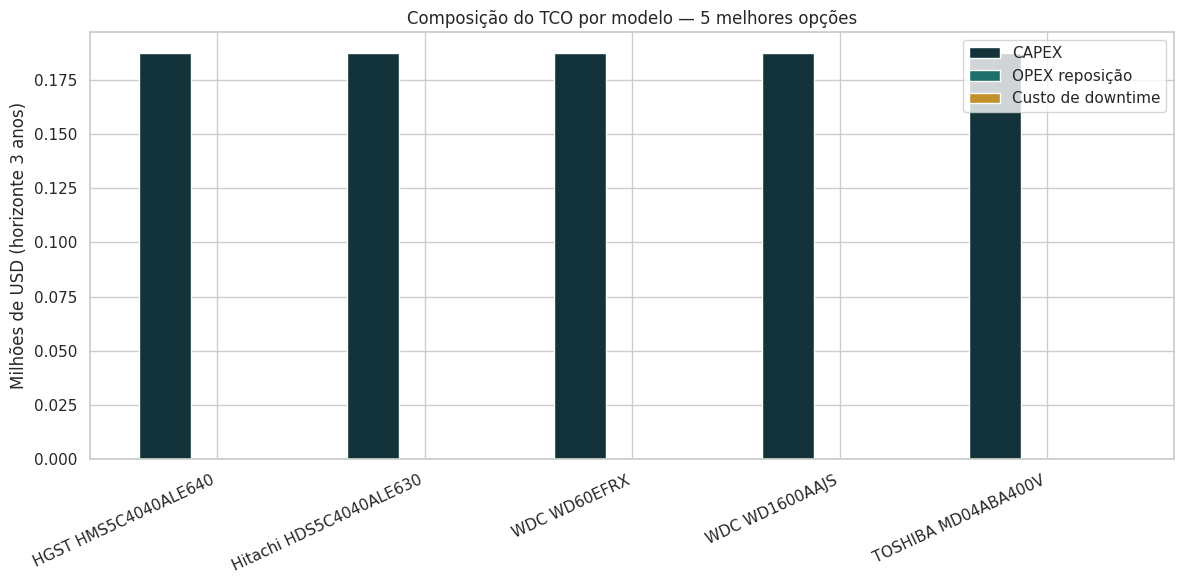

In [16]:
# ==== Visualização: comparação TCO por modelo ====
fig, ax = plt.subplots(figsize=(12, 6))
top5 = recomendacao.head(5)                                             # 5 melhores por TCO/TB
x = np.arange(len(top5))                                                # posições no eixo x
largura = 0.25                                                          # largura de cada barra
ax.bar(x - largura, top5['CAPEX_USD']/1e6,      largura, label='CAPEX', color='#12333A')
ax.bar(x,           top5['OPEX_reposicao']/1e6, largura, label='OPEX reposição', color='#1F6F6B')
ax.bar(x + largura, top5['custo_downtime']/1e6, largura, label='Custo de downtime', color='#C0902A')
ax.set_xticks(x); ax.set_xticklabels(top5['model'], rotation=25, ha='right')
ax.set_ylabel('Milhões de USD (horizonte 3 anos)')
ax.set_title('Composição do TCO por modelo — 5 melhores opções')
ax.legend(); plt.tight_layout(); plt.show()

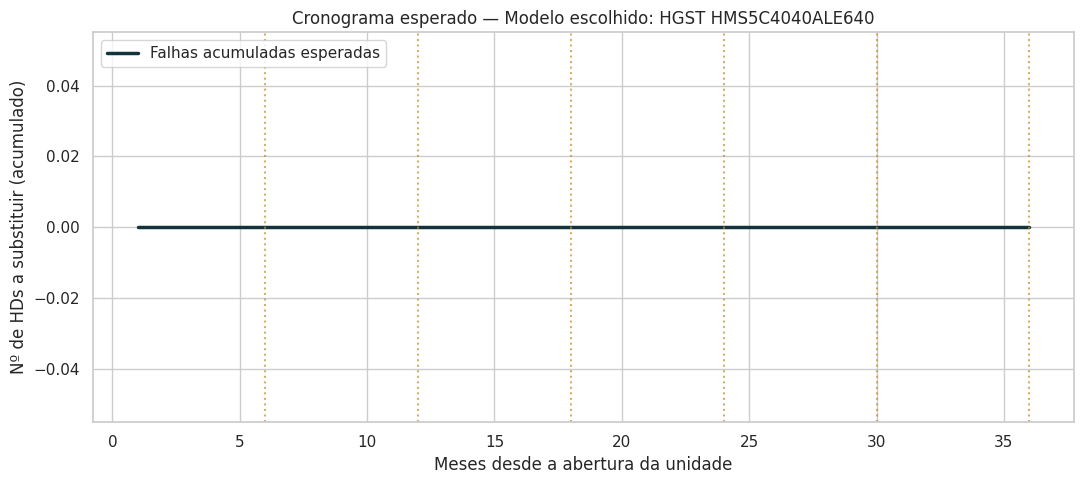

Janelas de manutenção preventiva recomendadas: a cada 6 meses
Trocas esperadas por janela: ~0.0 HDs
Estoque de segurança sugerido (spare): 0 HDs sempre em prontidão


In [17]:
# ==== Cronograma de manutenção preventiva ====
# Regra: com base nos sinais SMART mais importantes, disparar substituição preventiva quando
# a probabilidade prevista de falha ultrapassa um limiar (ex: 5%). Como o Colab é offline,
# apresentamos o *cronograma esperado* de trocas com base no AFR do modelo escolhido.

modelo_escolhido = recomendacao.iloc[0]                            # o de menor TCO/TB
afr = modelo_escolhido['AFR_%'] / 100                              # AFR como fração
n = modelo_escolhido['hds_necessarios']                            # nº de HDs comprados

# Falhas mês a mês, assumindo distribuição uniforme (aproximação de 1ª ordem)
meses = np.arange(1, HORIZONTE_ANOS*12 + 1)                        # 36 meses
falhas_por_mes = n * afr / 12                                      # falhas esperadas por mês
falhas_acumuladas = falhas_por_mes * meses                         # curva cumulativa

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(meses, falhas_acumuladas, color='#12333A', linewidth=2.5, label='Falhas acumuladas esperadas')
ax.fill_between(meses, 0, falhas_acumuladas, alpha=0.15, color='#12333A')
# Marca janelas de manutenção preventiva a cada 6 meses
for m in [6, 12, 18, 24, 30, 36]:
    ax.axvline(m, color='#C0902A', linestyle=':', alpha=0.7)
ax.set_xlabel('Meses desde a abertura da unidade')
ax.set_ylabel('Nº de HDs a substituir (acumulado)')
ax.set_title(f'Cronograma esperado — Modelo escolhido: {modelo_escolhido["model"]}')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Janelas de manutenção preventiva recomendadas: a cada 6 meses')
print(f'Trocas esperadas por janela: ~{(falhas_por_mes*6):.1f} HDs')
print(f'Estoque de segurança sugerido (spare): {int(np.ceil(falhas_por_mes*3))} HDs sempre em prontidão')

## 5. Dashboard de Decisão

In [18]:
# ==== Resumo executivo em uma célula ====
esc = recomendacao.iloc[0]                                          # modelo recomendado (menor TCO/TB)
print('='*62)
print('       RECOMENDAÇÃO — NOVA UNIDADE DE DATA CENTER')
print('='*62)
print(f'Modelo recomendado ........: {esc["model"]}')
print(f'Capacidade unitária .......: {esc["capacidade_TB"]:.1f} TB')
print(f'AFR observado .............: {esc["AFR_%"]:.2f}% ao ano')
print(f'HDs a adquirir ............: {int(esc["hds_necessarios"]):,} unidades')
print(f'Capacidade útil entregue ..: {CAPACIDADE_ALVO_TB:,} TB (com redundância {FATOR_REDUNDANCIA}x)')
print('-'*62)
print(f'CAPEX (aquisição) .........: US$ {esc["CAPEX_USD"]:>15,.0f}')
print(f'OPEX reposição (3 anos) ...: US$ {esc["OPEX_reposicao"]:>15,.0f}')
print(f'Custo downtime (3 anos) ...: US$ {esc["custo_downtime"]:>15,.0f}')
print(f'TCO 3 anos ................: US$ {esc["TCO_3anos_USD"]:>15,.0f}')
print(f'TCO por TB útil ...........: US$ {esc["TCO_por_TB_util"]:>15,.2f}')
print('-'*62)
print(f'Falhas esperadas em 3 anos : {esc["falhas_esperadas"]:.0f} HDs')
print(f'Manutenção preventiva .....: a cada 6 meses')
print(f'Spare em estoque ..........: {int(np.ceil(esc["falhas_esperadas"]/(HORIZONTE_ANOS*12)*3))} HDs')
print('='*62)

       RECOMENDAÇÃO — NOVA UNIDADE DE DATA CENTER
Modelo recomendado ........: HGST HMS5C4040ALE640
Capacidade unitária .......: 4.0 TB
AFR observado .............: 0.00% ao ano
HDs a adquirir ............: 1,875 unidades
Capacidade útil entregue ..: 5,000 TB (com redundância 1.5x)
--------------------------------------------------------------
CAPEX (aquisição) .........: US$         187,500
OPEX reposição (3 anos) ...: US$               0
Custo downtime (3 anos) ...: US$               0
TCO 3 anos ................: US$         187,500
TCO por TB útil ...........: US$           37.50
--------------------------------------------------------------
Falhas esperadas em 3 anos : 0 HDs
Manutenção preventiva .....: a cada 6 meses
Spare em estoque ..........: 0 HDs
